In [ ]:
import io
import zipfile
import pandas as pd
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt

# я вытащили коды стран, также их названия как на русском так и на англе
ISO_RU = {
    "DEU": "Германия", "USA": "США", "GBR": "Великобритания", "CAN": "Канада",
    "FRA": "Франция", "NLD": "Нидерланды", "ITA": "Италия", "ESP": "Испания",
    "CHN": "Китай", "CZE": "Чехия", "POL": "Польша", "FIN": "Финляндия",
    "AUT": "Австрия", "HUN": "Венгрия", "CHE": "Швейцария", "AUS": "Австралия",
    "JPN": "Япония", "KOR": "Южная Корея", "ARE": "ОАЭ", "TUR": "Турция",
    "EST": "Эстония", "LVA": "Латвия", "LTU": "Литва", "SVK": "Словакия",
    "SVN": "Словения", "SWE": "Швеция", "NOR": "Норвегия", "DNK": "Дания",
    "BEL": "Бельгия", "PRT": "Португалия", "GRC": "Греция", "IRL": "Ирландия",
    "BGR": "Болгария", "ROU": "Румыния", "HRV": "Хорватия", "CYP": "Кипр",
    # ну и тут страны бывшие советские еще добавила
    "ARM": "Армения", "KAZ": "Казахстан", "KGZ": "Киргизия", "BLR": "Беларусь",
    "AZE": "Азербайджан", "GEO": "Грузия", "UZB": "Узбекистан", "MDA": "Молдова",
    "TJK": "Таджикистан", "TKM": "Туркменистан", "UKR": "Украина",
}


def _read_csv_from_input(path):
    if path.lower().endswith(".zip"):
        with zipfile.ZipFile(path) as z:
            # ищу data.csv
            name = next(n for n in z.namelist() if n.endswith("data.csv"))
            with z.open(name) as f:
                return pd.read_csv(f)
    return pd.read_csv(path)


def load_unesco(path):
    df = _read_csv_from_input(path)
    # вот тут беру колонку с геопозицией, годом, количеством, прямо как в файле

    out = pd.DataFrame({
        "country": df["geoUnit"].map(lambda c: ISO_RU.get(str(c), str(c))),
        "year": pd.to_numeric(df["year"], errors = "coerce"),
        "students": pd.to_numeric(df["value"], errors = "coerce"),
    }).dropna(subset=["students"])
    out = out[out["students"] > 0]
    return out


def best_year(df, min_countries = 10): #беру послдение года как самые псевдо достоверные
    cnt = df.groupby("year")["country"].nunique()
    full = cnt[cnt >= min_countries]
    return int(full.index.max()) if len(full) else int(df["year"].max())


def analyze_unesco(df, top_n = 12, year = None, save = True):
    if df.empty:
        print("Нет данных для анализа.")
        return
    if year is None:
        year = best_year(df)
    data = df[df["year"] == year]
    g = (data.groupby("country")["students"].sum()
             .sort_values(ascending=False).head(top_n))

    fig, ax = plt.subplots(figsize = (10, 5))
    ax.barh(g.index[::-1], g.values[::-1], color = "red")
    ax.set_xlabel("число студентов из РФ")
    ax.set_title(f"куда едут учиться из РФ {year} (UNESCO)")
    for i, v in enumerate(g.values[::-1]):
        ax.text(v, i, f" {int(v):,}".replace(",", " "), va = "center")
    plt.tight_layout()
    plt.show()

    print(f"топ стран за {year} год")
    print(g.astype(int).to_string())

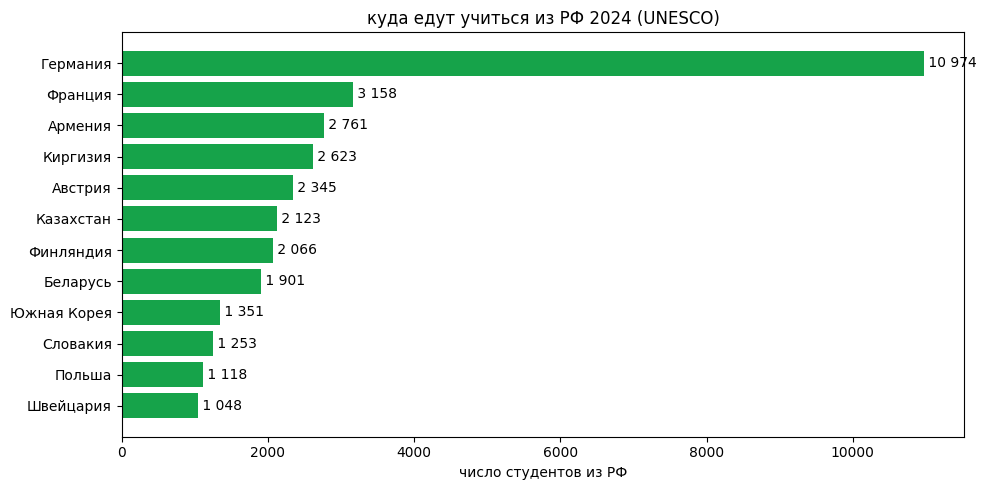

топ стран за 2024 год
country
Германия       10974
Франция         3158
Армения         2761
Киргизия        2623
Австрия         2345
Казахстан       2123
Финляндия       2066
Беларусь        1901
Южная Корея     1351
Словакия        1253
Польша          1118
Швейцария       1048


In [ ]:
df = load_unesco("/content/indicator-data-export_26604.zip")
analyze_unesco(df)

In [ ]:
df.to_csv("unesco_students.csv", index = False)